# Feigelson Chapter 7 pre-class assignment

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In this pre-class assignment, we're going to examine data from the SDSS quasar catalog from SDSS DR5 [Schneider et al. 2007](http://adsabs.harvard.edu/abs/2007AJ....134..102S).  This dataset has 77,429 quasars and quite a bit of information on each one, including magnitudes in 5 bands as well as a cosmological redshift.  Unlike the last assignment, we're going to use magnitudes in various bands rather than the redshift!

In [2]:
# reads in i and z band magnitudes and errors
QSO_i_mag, QSO_i_errors, QSO_z_mag, QSO_z_errors = np.loadtxt("SDSS_QSO.dat",skiprows=1,usecols=[8,9,10,11],unpack=True)

# remove what appears to be bad data from the sample
QSO_i_reduced = QSO_i_mag[QSO_i_mag >= 16.0]
QSO_z_reduced = QSO_z_mag[QSO_i_mag >= 16.0]
QSO_i_errors_reduced = QSO_i_errors[QSO_i_mag >= 16.0]
QSO_z_errors_reduced = QSO_z_errors[QSO_i_mag >= 16.0]



First, plot all of the data (both the raw data and, separately, the reduced data) as a scatter plot to see what it looks like.

Now, let's plot some of the error bars to get a sense of the errors in the data.  There are far too many data points to plot the errors for every quasar and make sense of it (about 77,000 points in the reduced dataset).  So, let's pick a subset of the points - say 0.1% of them - and plot the errors of those using the pyplot [errorbar](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.errorbar) method.

Hint: you can do this without loops by using [numpy.random.random](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.random.html#numpy.random.random) to generate a boolean array, as follows:

```
bool_array = np.random.random(QSO_i_reduced.size) < 0.001
```

And use that to subselect data in the way that I did in the previous cell.

<ErrorbarContainer object of 3 artists>

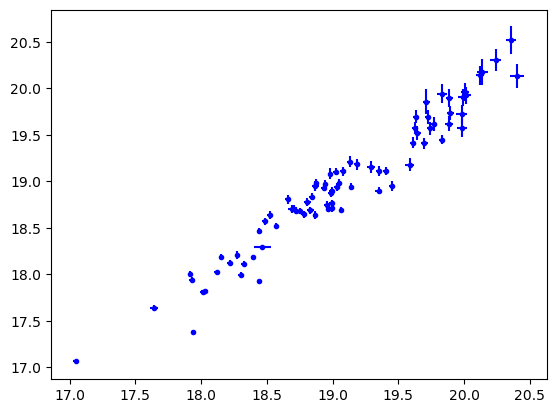

In [3]:
bool_array = np.random.random(QSO_i_reduced.size) < 0.001

QSOi = QSO_i_reduced[bool_array]
QSOierr = QSO_i_errors_reduced[bool_array]
QSOz = QSO_z_reduced[bool_array]
QSOzerr = QSO_z_errors_reduced[bool_array]

plt.errorbar(QSOi,QSOz,xerr=QSOierr,yerr=QSOzerr,fmt='b.')

Why do you think you see the pattern that you see in the errors?

**put your answer here!**

(16.0, 22.0)

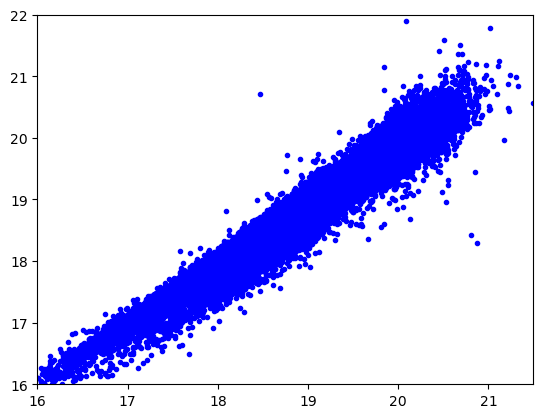

In [4]:
plt.plot(QSO_i_reduced, QSO_z_reduced,'b.')
plt.xlim(16.0,21.5)
plt.ylim(16.0,22)

Now, we're going to implement the Ordinary Least Squares method to find the best-fit line to the data (equation 7.6 in Feigelson).  Do so without using loops - recall that numpy arrays have built-in methods to get mean values, sums, etc. and you can even use that when you multiple arrays together.  So, for example, for an array ```a``` that contains a bunch of values, you can get the mean value, subtract it off of the array ```a```, and then sum the square of the resulting array in this way:

```
amean = a.mean()
((a-amean)**2).sum()
```

Which is equivalent to:

$\bar{a} = \frac{1}{N}\sum_{i=1}^{N} a_i$

$\sum_{i=1}^{N} (a_i - \bar{a})^2$

After you've implemented that method, ensure that your values for the slope and intercept give you reasonable values by plotting them!

In [5]:
def OLS(x,y):
    # fit for y = mx + b
    xmean = x.mean()
    ymean = y.mean()
    
    m = ((x-xmean)*(y-ymean)).sum() / ((x-xmean)**2).sum()
    print(m)
    
    b = ymean - m*xmean
    
    return m,b

m,b = OLS(QSO_i_reduced, QSO_z_reduced)
    
print(m,b)

x = np.linspace(18,22)
y = m*x+b

0.9826333604353616
0.9826333604353616 0.24014398355032895


(17.5, 22.0)

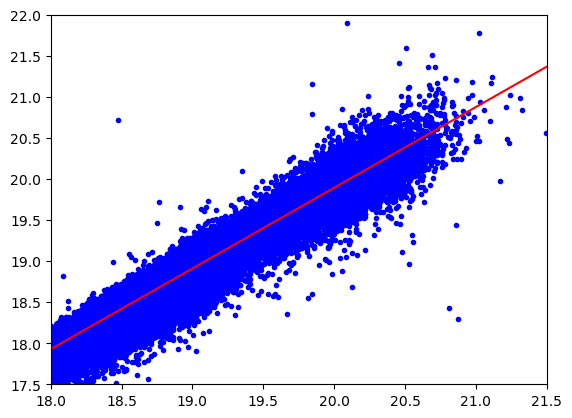

In [6]:
plt.plot(QSO_i_reduced, QSO_z_reduced,'b.',x,y,'r-')
plt.xlim(18.0,21.5)
plt.ylim(17.5,22)

Now, use the scipy [linear regression method](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.linregress.html) on the same data.  Do you get the same slope and intercept?

In [7]:
import scipy.stats as scistat

scistat.linregress(QSO_i_reduced,QSO_z_reduced)

LinregressResult(slope=np.float64(0.9826333604353583), intercept=np.float64(0.2401439835503929), rvalue=np.float64(0.9701924643965611), pvalue=np.float64(0.0), stderr=np.float64(0.0008833006881487681), intercept_stderr=np.float64(0.016805098338768757))

Now, we're going to do a weighted least-squares regression, as described in Section 7.4 of Feigelson.  How do the resulting values for the slope and intercept differ?  Put them both on the same plot along with your data and comment on the difference.

**IMPORTANT NOTE:** The expressions for $\bar{X}_{wt}$ and $\bar{Y}_{wt}$ are incorrect in Feigelson equation 7.37.  The expression for $\bar{X}_{wt}$ should be:

$\bar{X}_{wt} = \frac{\sum_{i=1}^{N}\frac{X_i}{\sigma^2_{Y,i}} }{ \sum_{i=1}^{N}\frac{1}{\sigma^2_{Y,i}} }$

And the expression for $\bar{Y}_{wt}$ is similarly missing a term in the denominator.

0.011 9.999 0.05576624099880849
18.419653958156008 18.311545112542472
m: 0.9732690829358732
b: 0.38426539669184834 18.311545112542472 17.927279715850624
0.9732690829358732 0.38426539669184834


(17.5, 22.0)

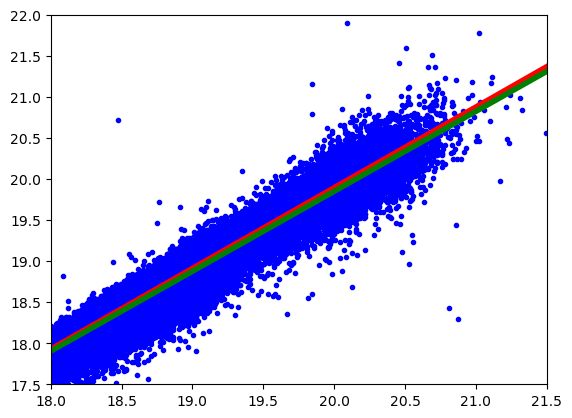

In [8]:
def weighted_OLS(x,y,xerr,yerr):
    # fit for y = mx + b
    
    print(yerr.min(),yerr.max(),yerr.mean())
    # weighted mean
    xmean = (x/yerr**2).sum()/(1/yerr**2).sum()
    ymean = (y/yerr**2).sum()/(1/yerr**2).sum()
    
    print(xmean,ymean)
    
    m = ((x-xmean)*(y-ymean)/yerr**2).sum() / ((x-xmean)**2/yerr**2).sum()
    print("m:",m)
    
    b = ymean - m*xmean
    
    print("b:", b, ymean, m*xmean)
    return m,b



m,b = weighted_OLS(QSO_i_reduced[QSO_z_errors_reduced>0.01], 
                   QSO_z_reduced[QSO_z_errors_reduced>0.01],
                   QSO_i_errors_reduced[QSO_z_errors_reduced>0.01],
                   QSO_z_errors_reduced[QSO_z_errors_reduced>0.01])


#m,b = weighted_OLS(QSOi,QSOz,1,1)
print(m,b)

xnew = np.linspace(18,22)
ynew = m*x+b

plt.plot(QSO_i_reduced, QSO_z_reduced,'b.',x,y,'r-',xnew,ynew,'g-',linewidth=4)
plt.xlim(18.0,21.5)
plt.ylim(17.5,22)

Comment on the difference here!

(0.0, 0.2)

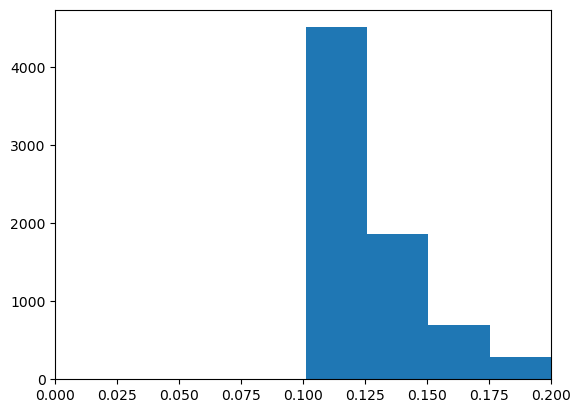

In [9]:
plt.hist(QSO_z_errors_reduced[QSO_z_errors_reduced>0.1],bins=400)
plt.xlim(0,0.2)